  06b_paper_figures_seaborn
  DPI: 600 | 폰트: Malgun Gothic
데이터 로드 완료

[그림 2] gold_sql 검증 결과...


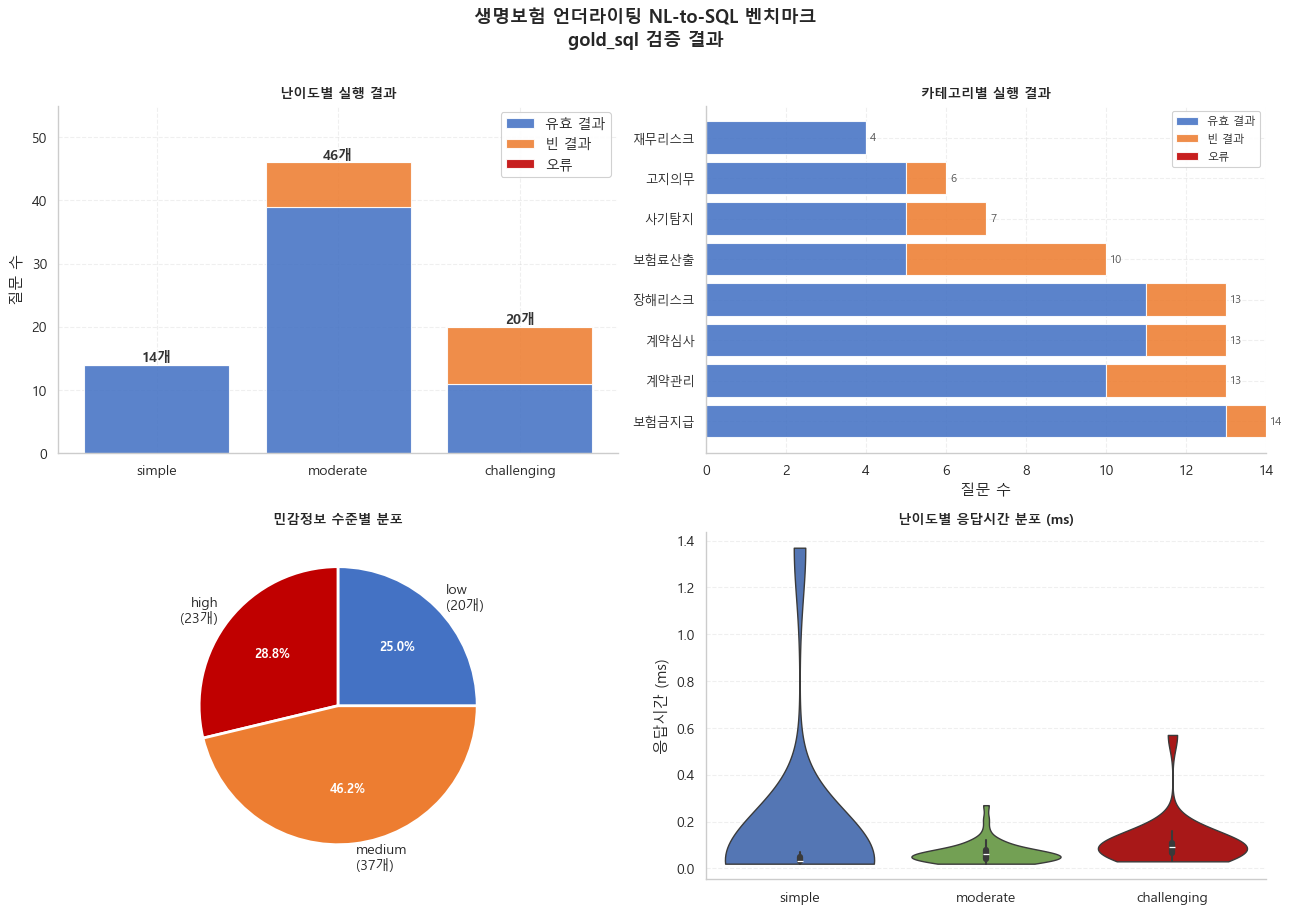

  저장: fig2_gold_sql_validation.png

[그림 3] T2S vs SL 비교 종합...


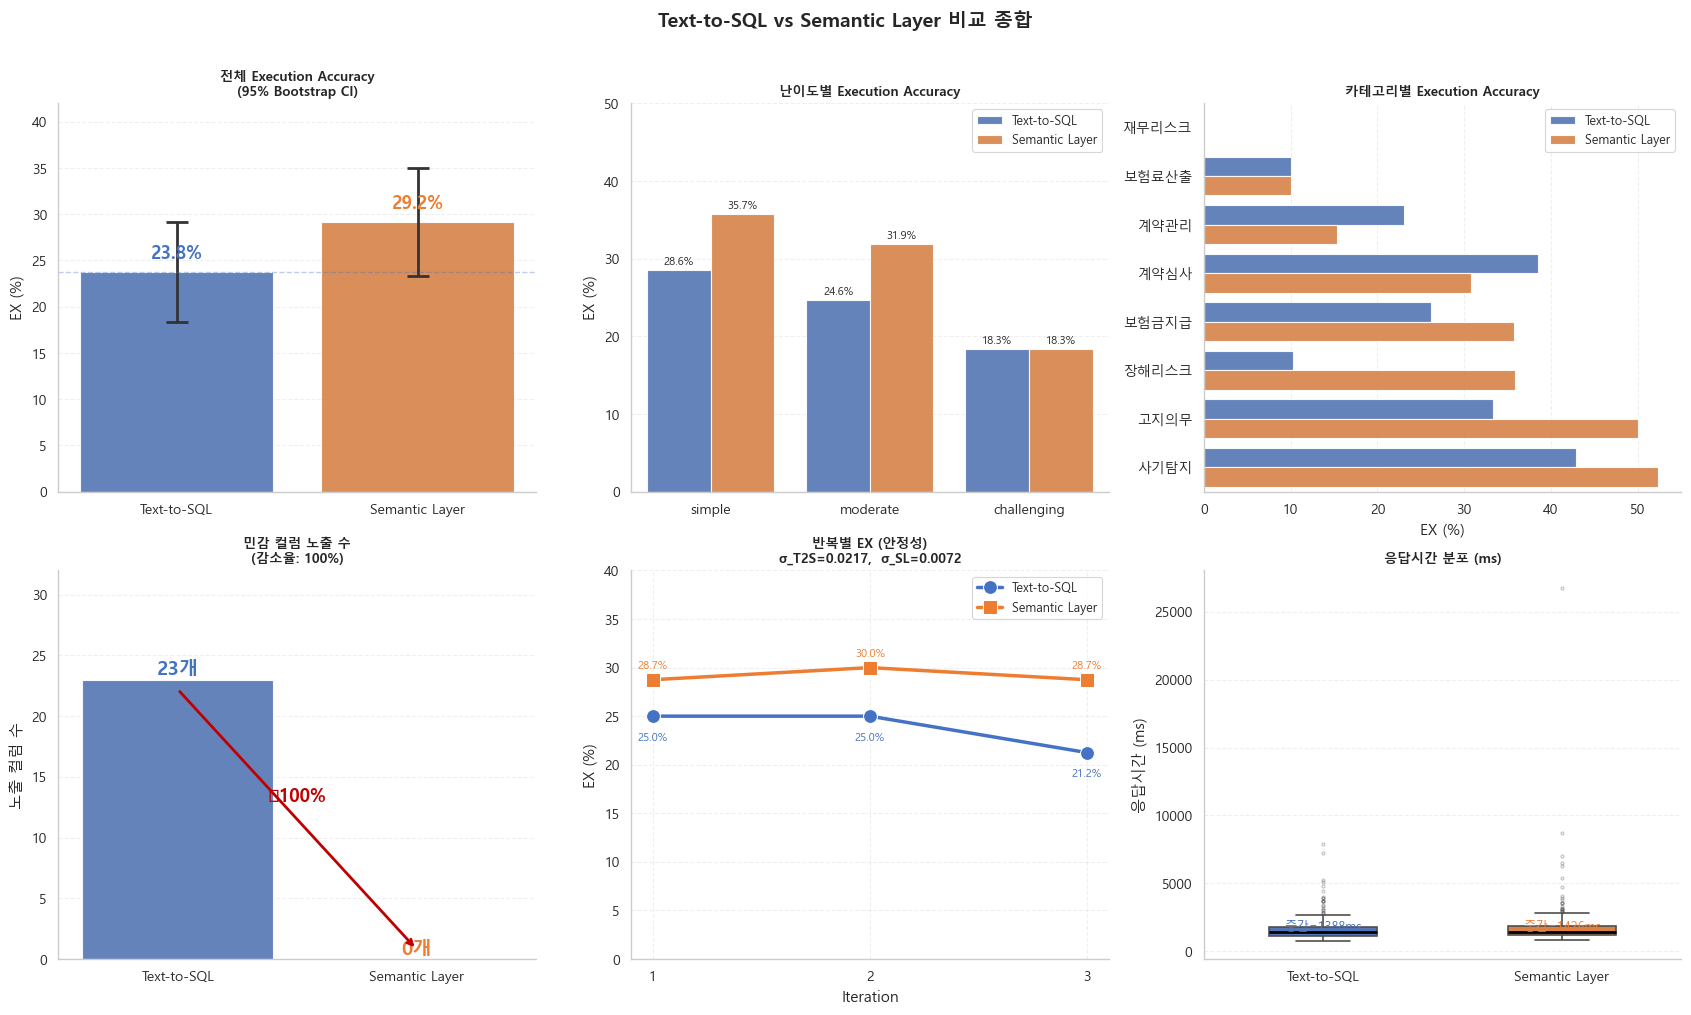

  저장: fig3_comparison.png

[그림 4] 민감정보 심층 분석...


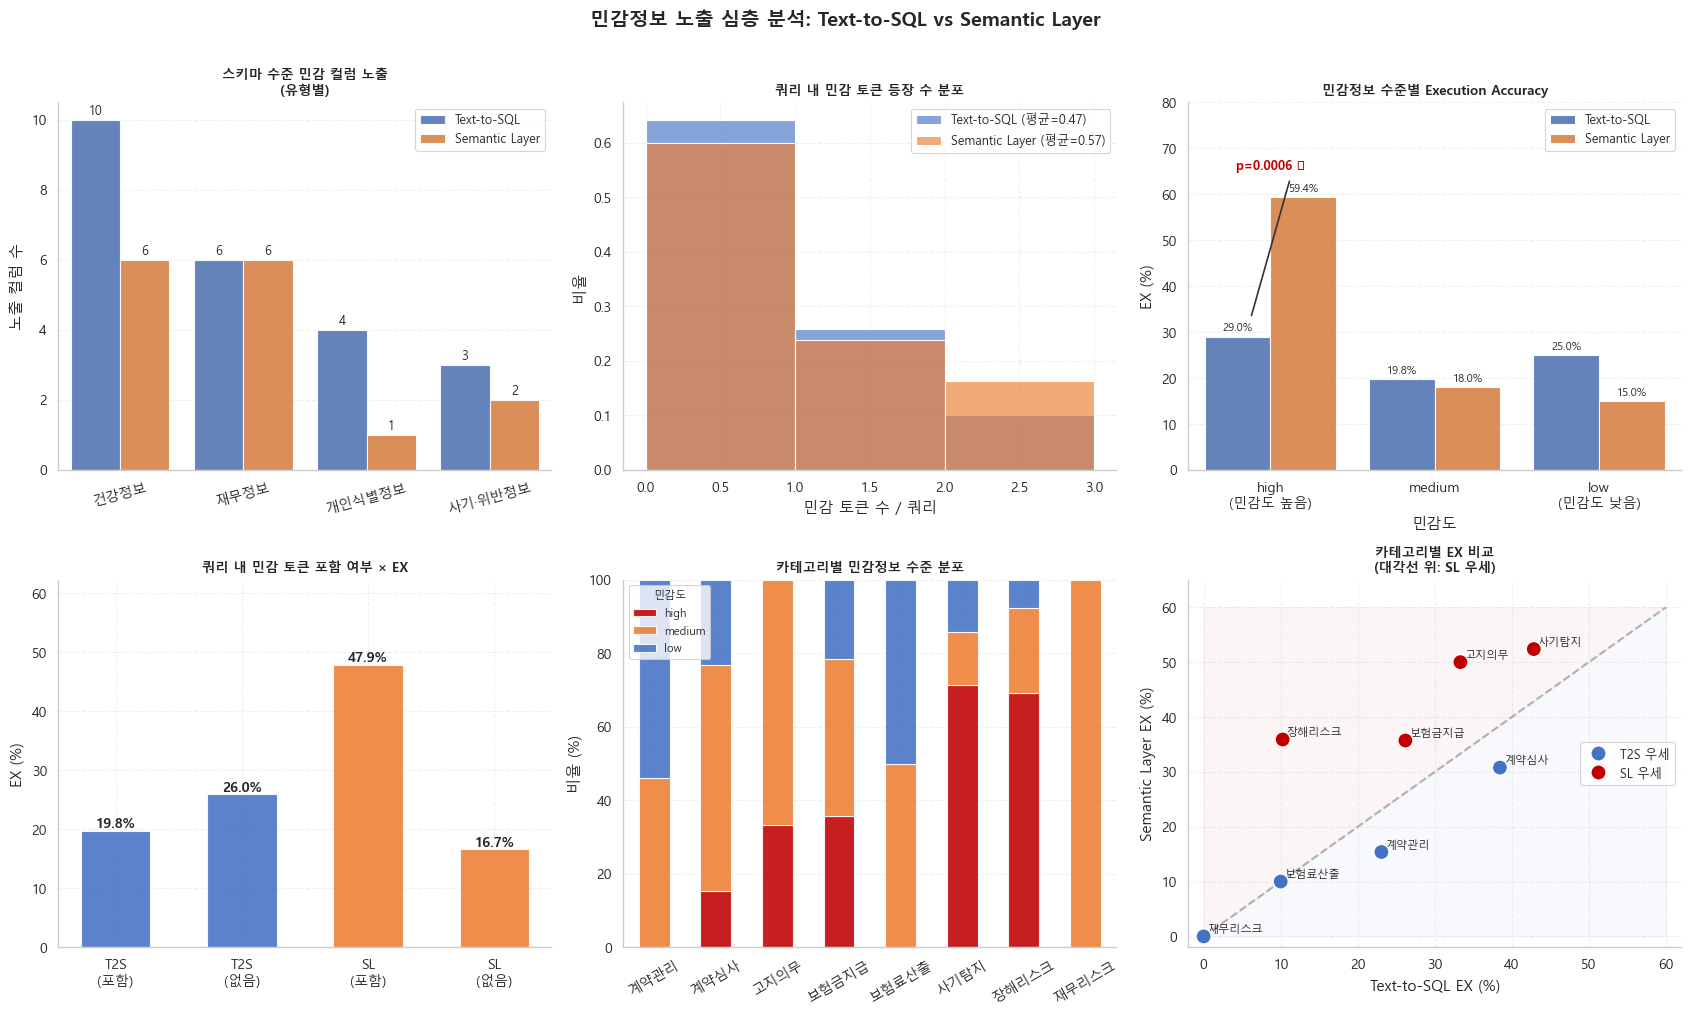

  저장: fig4_sensitivity_analysis.png

[그림 5] 오류 유형 비교...


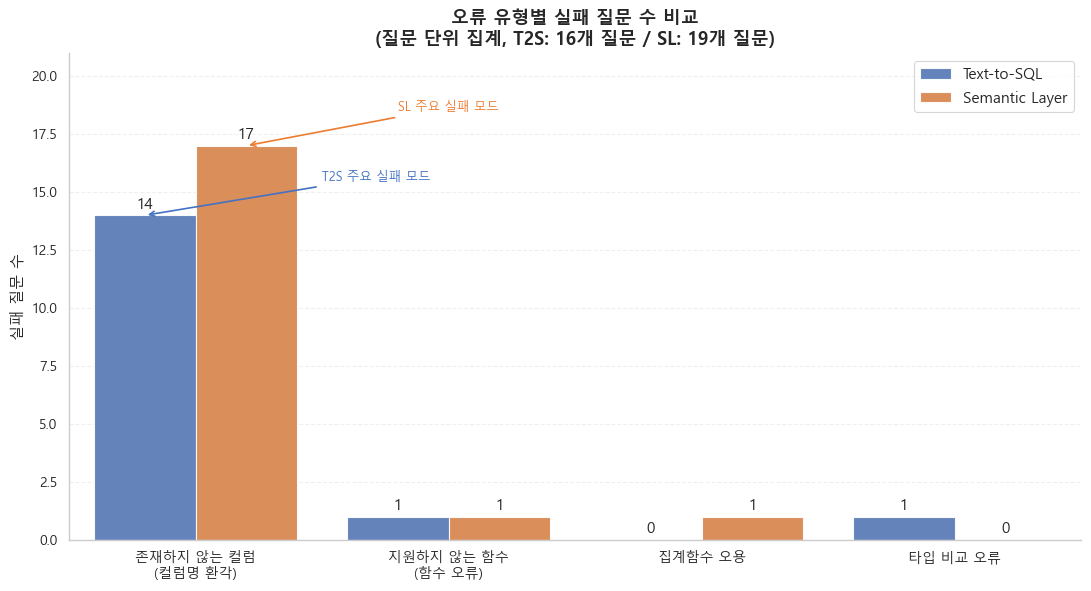

  저장: fig5_error_analysis.png

[그림 6] Jagged Frontier...


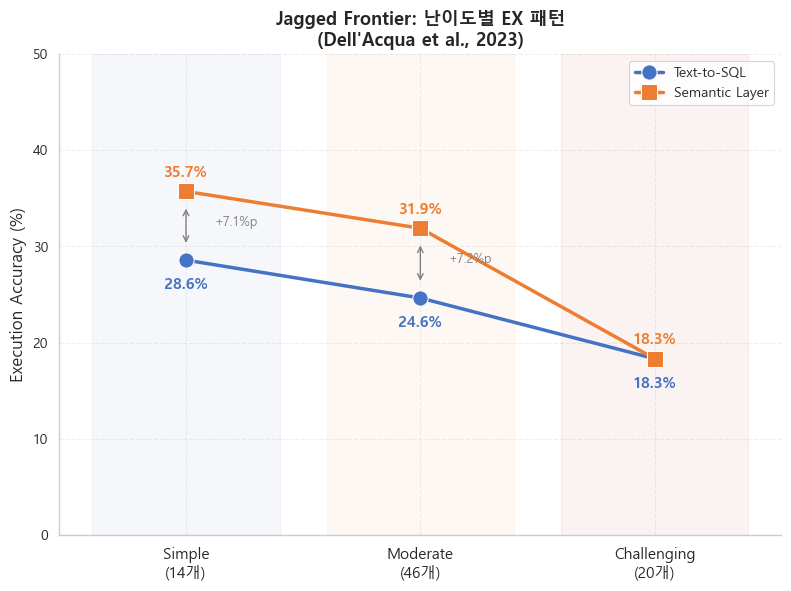

  저장: fig6_jagged_frontier.png

[그림 7] 선택적 캡슐화 산점도...


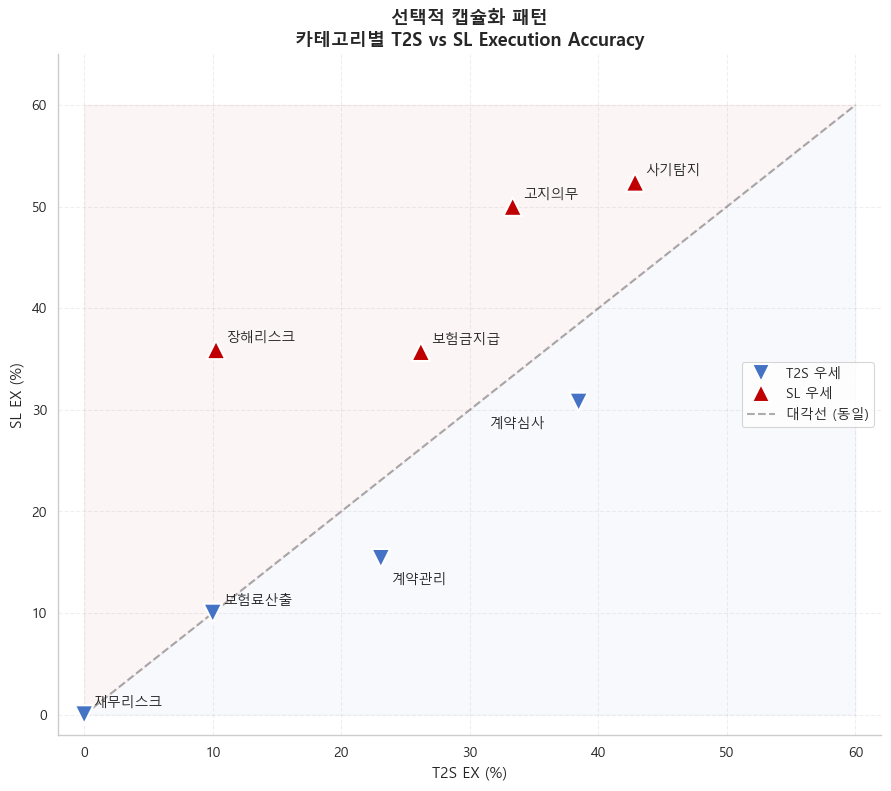

  저장: fig7_selective_encapsulation.png

[그림 8] Semantic Layer 개념 구조도 (matplotlib)...


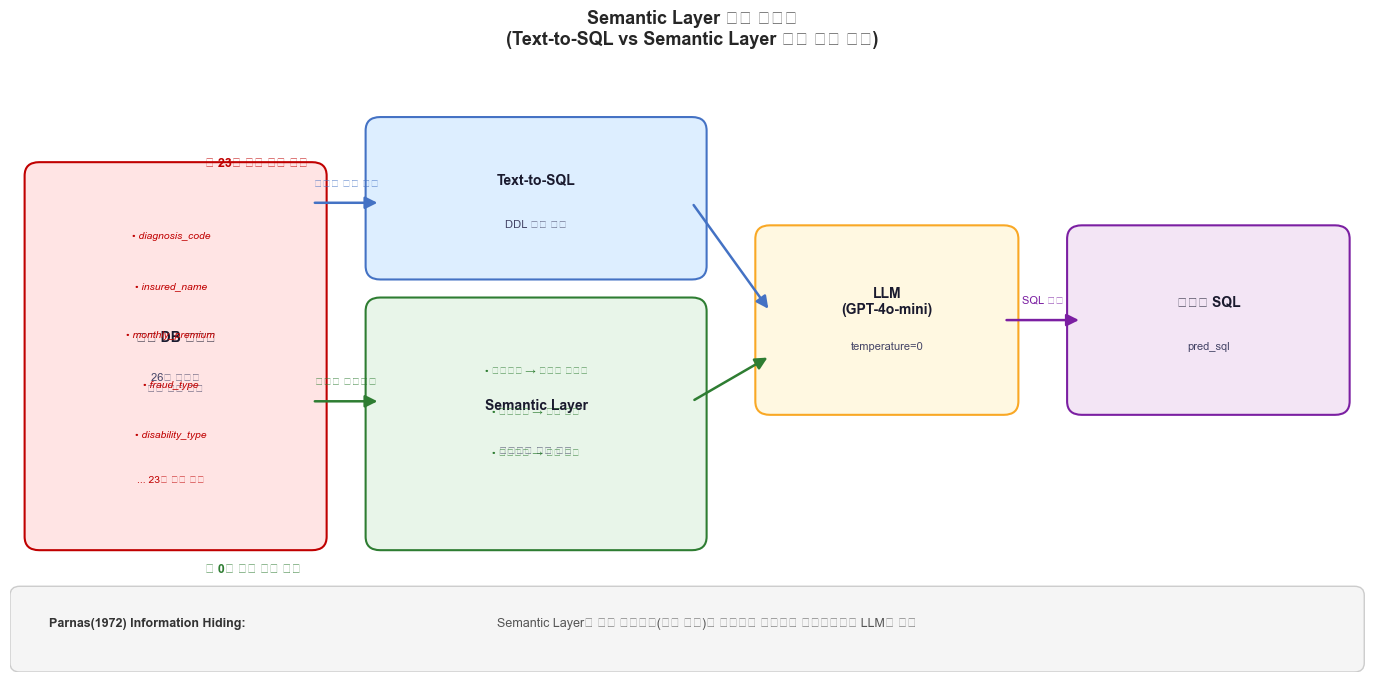

  저장: fig8_semantic_layer_concept.png

  ✅ Seaborn 버전 논문 그림 일괄 생성 완료
  fig2_gold_sql_validation.png                    684 KB
  fig3_comparison.png                            1024 KB
  fig4_sensitivity_analysis.png                  1396 KB
  fig5_error_analysis.png                         305 KB
  fig6_jagged_frontier.png                        418 KB
  fig7_selective_encapsulation.png                513 KB
  fig8_semantic_layer_concept.png                 454 KB

  저장 경로: C:\Users\miy\Downloads\1000_논문투고\1_양문일_교신저자\23_언더라이팅_Text_to_SQL\insurance-underwriting-nl2sql-benchmark\results\figures\paper_seaborn


In [3]:
# ============================================================
# 06b_paper_figures_seaborn.ipynb
# 논문 그림 일괄 생성 — Seaborn 버전
# 그림 2~7: seaborn 기반 / 그림 8: matplotlib 개념 구조도
# ============================================================

# %% [1] 라이브러리 & 경로
import os, re, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
from pathlib import Path
from scipy import stats

ROOT = Path(os.getcwd())
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RAW_DIR = ROOT / "results" / "raw"
FIG_DIR = ROOT / "results" / "figures" / "paper_seaborn"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── 폰트
font_candidates = ["Malgun Gothic", "NanumGothic", "AppleGothic", "DejaVu Sans"]
available = {f.name for f in fm.fontManager.ttflist}
KOR_FONT  = next((f for f in font_candidates if f in available), "DejaVu Sans")
matplotlib.rc("font", family=KOR_FONT)
matplotlib.rc("axes", unicode_minus=False)

# ── Seaborn 테마 (학술지 스타일)
sns.set_theme(
    style="whitegrid",
    context="paper",
    font=KOR_FONT,
    rc={
        "axes.spines.top"   : False,
        "axes.spines.right" : False,
        "grid.alpha"        : 0.3,
        "grid.linestyle"    : "--",
        "axes.labelsize"    : 11,
        "xtick.labelsize"   : 10,
        "ytick.labelsize"   : 10,
        "legend.fontsize"   : 10,
        "figure.facecolor"  : "white",
        "axes.facecolor"    : "white",
    }
)

DPI   = 600
C_T2S = "#4472C4"
C_SL  = "#ED7D31"
C_HI  = "#C00000"
C_MED = "#ED7D31"
C_LOW = "#4472C4"
PAL   = {"Text-to-SQL": C_T2S, "Semantic Layer": C_SL}

DIFF_ORDER = ["simple", "moderate", "challenging"]
SIL_ORDER  = ["high", "medium", "low"]

SENSITIVE_TOKENS = {
    "건강정보"    : ["diagnosis_code","prior_diagnosis_code","disability_type",
                     "disability_subtype","disability_body_part","disability_payment_rate",
                     "cdr_score","primary_diagnosis","death_cause","icd_code"],
    "재무정보"    : ["total_paid_premium","monthly_premium","annual_premium",
                     "surrender_value","loan_balance","paid_amount"],
    "개인식별정보": ["birth_date","insured_name","death_date","missing_period_days"],
    "사기·위반정보": ["fraud_type","causation_proven","violation_type"],
}
ALL_SENSITIVE = [t for ts in SENSITIVE_TOKENS.values() for t in ts]

def count_sensitive(sql):
    sql_l = sql.lower() if isinstance(sql, str) else ""
    return sum(1 for t in ALL_SENSITIVE
               if re.search(r'\b' + re.escape(t) + r'\b', sql_l))

print("=" * 55)
print("  06b_paper_figures_seaborn")
print("=" * 55)
print(f"  DPI: {DPI} | 폰트: {KOR_FONT}")


# %% [2] 데이터 로드
df_t2s = pd.read_csv(RAW_DIR / "text2sql_results_raw.csv",        encoding="utf-8-sig")
df_sl  = pd.read_csv(RAW_DIR / "semantic_layer_results_raw.csv",  encoding="utf-8-sig")
df_val = pd.read_csv(RAW_DIR / "gold_sql_validation.csv",         encoding="utf-8-sig")

with open(RAW_DIR / "text2sql_summary.json",            encoding="utf-8") as f: t2s_sum  = json.load(f)
with open(RAW_DIR / "semantic_layer_summary.json",      encoding="utf-8") as f: sl_sum   = json.load(f)
with open(RAW_DIR / "sensitivity_analysis_report.json", encoding="utf-8") as f: sens_rep = json.load(f)

df_t2s["method"]   = "Text-to-SQL"
df_sl["method"]    = "Semantic Layer"
df_all             = pd.concat([df_t2s, df_sl], ignore_index=True)
df_t2s["sens_cnt"] = df_t2s["pred_sql"].apply(count_sensitive)
df_sl["sens_cnt"]  = df_sl["pred_sql"].apply(count_sensitive)
df_all["sens_cnt"] = df_all["pred_sql"].apply(count_sensitive)

q1p = ROOT / "benchmark" / "questionset_v2_part1.json"
q2p = ROOT / "benchmark" / "questionset_v2_part2.json"
def load_qs(p):
    with open(p, encoding="utf-8") as f: d = json.load(f)
    return d if isinstance(d, list) else d.get("questions", [])
df_qs = pd.DataFrame(load_qs(q1p) + load_qs(q2p))

print("데이터 로드 완료")


# ============================================================
# 그림 2: gold_sql 검증 결과
# ============================================================
# %% [3] 그림 2
print("\n[그림 2] gold_sql 검증 결과...")

diff_stats = (
    df_val.groupby("difficulty")
    .agg(전체=("status","count"),
         유효=("is_empty", lambda x: (~x[df_val.loc[x.index,"status"].eq("success")] | ~x).sum() ),
         빈결과=("is_empty", lambda x: x[df_val.loc[x.index,"status"]=="success"].sum()),
         오류=("status", lambda x: (x=="error").sum()),
         응답ms=("elapsed_ms","mean"))
    .reindex(DIFF_ORDER).round(2)
)
diff_stats["유효"] = (diff_stats["전체"]
                      - diff_stats["빈결과"]
                      - diff_stats["오류"])

cat_stats = (
    df_val.groupby("category")
    .agg(전체=("status","count"),
         빈결과=("is_empty", lambda x: x[df_val.loc[x.index,"status"]=="success"].sum()),
         오류=("status", lambda x: (x=="error").sum()))
    .sort_values("전체", ascending=False)
)
cat_stats["유효"] = cat_stats["전체"] - cat_stats["빈결과"] - cat_stats["오류"]

sil_counts = df_qs["sensitive_info_level"].value_counts().reindex(SIL_ORDER)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 2-1. 난이도별 stacked bar
ax = axes[0, 0]
bottom = np.zeros(3)
for col, color, lbl in [("유효","#4472C4","유효 결과"),
                         ("빈결과","#ED7D31","빈 결과"),
                         ("오류","#C00000","오류")]:
    vals = diff_stats[col].values
    ax.bar(DIFF_ORDER, vals, bottom=bottom, label=lbl,
           color=color, alpha=0.88, edgecolor="white", linewidth=0.8)
    bottom += vals
for i, d in enumerate(DIFF_ORDER):
    ax.text(i, diff_stats.loc[d,"전체"]+0.5, f'{int(diff_stats.loc[d,"전체"])}개',
            ha="center", fontsize=10, fontweight="bold", color="#333")
ax.set_title("난이도별 실행 결과", fontweight="bold")
ax.set_ylabel("질문 수")
ax.legend(loc="upper right", framealpha=0.9)
ax.set_ylim(0, 55)

# 2-2. 카테고리별 수평 stacked bar
ax = axes[0, 1]
cats = cat_stats.index.tolist()
y    = np.arange(len(cats))
left = np.zeros(len(cats))
for col, color, lbl in [("유효","#4472C4","유효 결과"),
                         ("빈결과","#ED7D31","빈 결과"),
                         ("오류","#C00000","오류")]:
    vals = cat_stats[col].values
    ax.barh(y, vals, left=left, label=lbl,
            color=color, alpha=0.88, edgecolor="white", linewidth=0.8)
    left += vals
ax.set_yticks(y); ax.set_yticklabels(cats, fontsize=9)
ax.set_title("카테고리별 실행 결과", fontweight="bold")
ax.set_xlabel("질문 수")
ax.legend(fontsize=8, framealpha=0.9)
for i, t in enumerate(cat_stats["전체"].values):
    ax.text(t+0.1, i, str(int(t)), va="center", fontsize=8, color="#555")

# 2-3. 민감정보 수준별 파이
ax = axes[1, 0]
wedges, texts, autotexts = ax.pie(
    sil_counts.values,
    labels=[f"{s}\n({int(c)}개)" for s, c in zip(SIL_ORDER, sil_counts.values)],
    colors=[C_HI, C_MED, C_LOW],
    autopct="%1.1f%%", startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2),
    textprops=dict(fontsize=10)
)
for at in autotexts: at.set_fontsize(9); at.set_color("white"); at.set_fontweight("bold")
ax.set_title("민감정보 수준별 분포", fontweight="bold")

# 2-4. 응답시간 — seaborn violinplot
ax = axes[1, 1]
succ_df = df_val[df_val["status"]=="success"].copy()
succ_df["난이도"] = pd.Categorical(succ_df["difficulty"], DIFF_ORDER, ordered=True)
sns.violinplot(data=succ_df, x="난이도", y="elapsed_ms",
               palette={"simple":"#4472C4","moderate":"#70AD47","challenging":"#C00000"},
               inner="box", cut=0, ax=ax, linewidth=1)
ax.set_title("난이도별 응답시간 분포 (ms)", fontweight="bold")
ax.set_ylabel("응답시간 (ms)")
ax.set_xlabel("")

plt.suptitle("생명보험 언더라이팅 NL-to-SQL 벤치마크\ngold_sql 검증 결과",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
p = FIG_DIR / "fig2_gold_sql_validation.png"
plt.savefig(p, dpi=DPI, bbox_inches="tight"); plt.show()
print(f"  저장: {p.name}")


# ============================================================
# 그림 3: T2S vs SL 비교 종합
# ============================================================
# %% [4] 그림 3
print("\n[그림 3] T2S vs SL 비교 종합...")

rng = np.random.default_rng(42)
def boot_ci(arr, n=5000):
    return np.percentile(
        [rng.choice(arr, size=len(arr), replace=True).mean() for _ in range(n)],
        [2.5, 97.5])

t2s_ci = boot_ci(df_t2s["ex"].values)
sl_ci  = boot_ci(df_sl["ex"].values)
t2s_ex = df_t2s["ex"].mean()
sl_ex  = df_sl["ex"].mean()

# 난이도별 long-form
diff_long = (
    df_all.groupby(["method","difficulty"])["ex"]
    .mean().reset_index()
    .rename(columns={"ex":"EX"})
)
diff_long["EX_pct"] = diff_long["EX"] * 100
diff_long["difficulty"] = pd.Categorical(diff_long["difficulty"], DIFF_ORDER, ordered=True)

# 카테고리별
cat_long = (
    df_all.groupby(["method","category"])["ex"]
    .mean().reset_index()
    .rename(columns={"ex":"EX"})
)
cat_long["EX_pct"] = cat_long["EX"] * 100

# 반복별
iter_long = (
    df_all.groupby(["method","iteration"])["ex"]
    .mean().reset_index()
    .rename(columns={"ex":"EX"})
)
iter_long["EX_pct"] = iter_long["EX"] * 100

fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# 3-1. 전체 EX + CI
ax = axes[0, 0]
methods  = ["Text-to-SQL", "Semantic Layer"]
ex_pcts  = [t2s_ex*100, sl_ex*100]
ci_lo    = [(t2s_ex - t2s_ci[0])*100, (sl_ex - sl_ci[0])*100]
ci_hi    = [(t2s_ci[1] - t2s_ex)*100, (sl_ci[1] - sl_ex)*100]
sns.barplot(x=methods, y=ex_pcts, palette=PAL, ax=ax,
            order=methods, alpha=0.9, edgecolor="white")
ax.errorbar(methods, ex_pcts, yerr=[ci_lo, ci_hi],
            fmt="none", color="#333", capsize=8, linewidth=2, capthick=2)
for i, (m, v) in enumerate(zip(methods, ex_pcts)):
    ax.text(i, v+1.5, f"{v:.1f}%", ha="center", fontsize=13, fontweight="bold",
            color=PAL[m])
ax.axhline(y=t2s_ex*100, color=C_T2S, linestyle="--", alpha=0.35, linewidth=1)
ax.set_title("전체 Execution Accuracy\n(95% Bootstrap CI)", fontweight="bold")
ax.set_ylabel("EX (%)"); ax.set_ylim(0, 42); ax.set_xlabel("")

# 3-2. 난이도별 EX
ax = axes[0, 1]
sns.barplot(data=diff_long, x="difficulty", y="EX_pct",
            hue="method", hue_order=["Text-to-SQL","Semantic Layer"],
            palette=PAL, ax=ax, alpha=0.9, edgecolor="white")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=8, padding=2)
ax.set_title("난이도별 Execution Accuracy", fontweight="bold")
ax.set_ylabel("EX (%)"); ax.set_xlabel("")
ax.set_ylim(0, 50)
ax.legend(title="", fontsize=9)

# 3-3. 카테고리별 EX (수평)
ax = axes[0, 2]
# 카테고리를 SL EX 기준 정렬
cat_order = (cat_long[cat_long["method"]=="Semantic Layer"]
             .sort_values("EX_pct", ascending=True)["category"].tolist())
sns.barplot(data=cat_long, y="category", x="EX_pct",
            hue="method", hue_order=["Text-to-SQL","Semantic Layer"],
            palette=PAL, order=cat_order, ax=ax, alpha=0.9, edgecolor="white",
            orient="h")
ax.set_title("카테고리별 Execution Accuracy", fontweight="bold")
ax.set_xlabel("EX (%)"); ax.set_ylabel("")
ax.legend(title="", fontsize=9)

# 3-4. 민감 컬럼 노출 수
ax = axes[1, 0]
t2s_exp = t2s_sum["sensitive_cols_exposed"]
sl_exp  = sl_sum["sensitive_cols_exposed"]
sns.barplot(x=methods, y=[t2s_exp, sl_exp], palette=PAL,
            order=methods, ax=ax, alpha=0.9, edgecolor="white")
ax.text(0, t2s_exp+0.4, f"{t2s_exp}개", ha="center", fontsize=14, fontweight="bold", color=C_T2S)
ax.text(1, sl_exp+0.4,  f"{sl_exp}개",  ha="center", fontsize=14, fontweight="bold", color=C_SL)
ax.annotate("", xy=(1, sl_exp+0.8), xytext=(0, t2s_exp-0.8),
            arrowprops=dict(arrowstyle="->", color=C_HI, lw=2))
ax.text(0.5, (t2s_exp+sl_exp)/2+1.5, "−100%",
        ha="center", color=C_HI, fontsize=13, fontweight="bold")
ax.set_title("민감 컬럼 노출 수\n(감소율: 100%)", fontweight="bold")
ax.set_ylabel("노출 컬럼 수"); ax.set_ylim(0, 32); ax.set_xlabel("")

# 3-5. 반복별 EX (선 그래프)
ax = axes[1, 1]
sns.lineplot(data=iter_long, x="iteration", y="EX_pct",
             hue="method", hue_order=["Text-to-SQL","Semantic Layer"],
             palette=PAL, ax=ax, linewidth=2.5,
             markers={"Text-to-SQL":"o","Semantic Layer":"s"},
             style="method", dashes=False, markersize=10)
for _, row in iter_long.iterrows():
    offset = -2.5 if row["method"]=="Text-to-SQL" else 1.2
    ax.text(row["iteration"], row["EX_pct"]+offset,
            f"{row['EX_pct']:.1f}%", ha="center", fontsize=8,
            color=PAL[row["method"]])
t2s_std = df_t2s.groupby("iteration")["ex"].mean().std()
sl_std  = df_sl.groupby("iteration")["ex"].mean().std()
ax.set_title(f"반복별 EX (안정성)\nσ_T2S={t2s_std:.4f},  σ_SL={sl_std:.4f}",
             fontweight="bold")
ax.set_xlabel("Iteration"); ax.set_ylabel("EX (%)")
ax.set_xticks([1,2,3]); ax.set_ylim(0, 40)
ax.legend(title="", fontsize=9)

# 3-6. 응답시간 — seaborn boxplot + stripplot
ax = axes[1, 2]
sns.boxplot(data=df_all, x="method", y="latency_ms",
            order=["Text-to-SQL","Semantic Layer"],
            palette=PAL, ax=ax, width=0.45,
            flierprops=dict(marker=".", markersize=4, alpha=0.3),
            linewidth=1.2, medianprops=dict(color="black", linewidth=2))
for i, (meth, col) in enumerate(zip(["Text-to-SQL","Semantic Layer"], [C_T2S, C_SL])):
    med = df_all[df_all["method"]==meth]["latency_ms"].median()
    ax.text(i, med+120, f"중간={med:.0f}ms", ha="center", fontsize=9, color=col)
ax.set_title("응답시간 분포 (ms)", fontweight="bold")
ax.set_ylabel("응답시간 (ms)"); ax.set_xlabel("")

plt.suptitle("Text-to-SQL vs Semantic Layer 비교 종합",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
p = FIG_DIR / "fig3_comparison.png"
plt.savefig(p, dpi=DPI, bbox_inches="tight"); plt.show()
print(f"  저장: {p.name}")


# ============================================================
# 그림 4: 민감정보 심층 분석
# ============================================================
# %% [5] 그림 4
print("\n[그림 4] 민감정보 심층 분석...")

schema_by_cat = sens_rep["schema_level"]["by_category"]
schema_long   = pd.DataFrame([
    {"유형": cat, "method": "Text-to-SQL",    "노출수": v["t2s"]}
    for cat, v in schema_by_cat.items()
] + [
    {"유형": cat, "method": "Semantic Layer", "노출수": v["sl"]}
    for cat, v in schema_by_cat.items()
])

sil_long = pd.DataFrame([
    {"method":"Text-to-SQL",    "민감도":s,
     "EX(%)":sens_rep["ex_by_sensitive_level"][s]["t2s_ex_pct"]}
    for s in SIL_ORDER
] + [
    {"method":"Semantic Layer", "민감도":s,
     "EX(%)":sens_rep["ex_by_sensitive_level"][s]["sl_ex_pct"]}
    for s in SIL_ORDER
])
sil_long["민감도"] = pd.Categorical(sil_long["민감도"], SIL_ORDER, ordered=True)

t2s_exp_ex = df_t2s[df_t2s["sens_cnt"]>0]["ex"].mean()*100
t2s_cln_ex = df_t2s[df_t2s["sens_cnt"]==0]["ex"].mean()*100
sl_exp_ex  = df_sl[df_sl["sens_cnt"]>0]["ex"].mean()*100
sl_cln_ex  = df_sl[df_sl["sens_cnt"]==0]["ex"].mean()*100

tok_df = pd.DataFrame({
    "조건": ["T2S\n(포함)", "T2S\n(없음)", "SL\n(포함)", "SL\n(없음)"],
    "EX(%)": [t2s_exp_ex, t2s_cln_ex, sl_exp_ex, sl_cln_ex],
    "method": ["Text-to-SQL","Text-to-SQL","Semantic Layer","Semantic Layer"],
    "투명도": ["포함","없음","포함","없음"],
})

cat_sil = df_qs.groupby(["category","sensitive_info_level"]).size().unstack(fill_value=0)
cat_sil = cat_sil.reindex(columns=SIL_ORDER, fill_value=0)
cat_sil_pct = cat_sil.div(cat_sil.sum(axis=1), axis=0)*100
cat_sil_melt = cat_sil_pct.reset_index().melt(
    id_vars="category", var_name="민감도", value_name="비율(%)")
cat_sil_melt["민감도"] = pd.Categorical(cat_sil_melt["민감도"], SIL_ORDER, ordered=True)

cat_t2s = df_t2s.groupby("category")["ex"].mean()*100
cat_sl  = df_sl.groupby("category")["ex"].mean()*100

fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# 4-1. 스키마 수준 유형별 노출
ax = axes[0, 0]
sns.barplot(data=schema_long, x="유형", y="노출수",
            hue="method", hue_order=["Text-to-SQL","Semantic Layer"],
            palette=PAL, ax=ax, alpha=0.9, edgecolor="white")
for container in ax.containers:
    ax.bar_label(container, fmt="%d", fontsize=9, padding=2)
ax.set_title("스키마 수준 민감 컬럼 노출\n(유형별)", fontweight="bold")
ax.set_ylabel("노출 컬럼 수"); ax.set_xlabel("")
ax.tick_params(axis="x", rotation=15)
ax.legend(title="", fontsize=9)

# 4-2. 쿼리 수준 토큰 분포 — seaborn histplot
ax = axes[0, 1]
t2s_avg = sens_rep["query_level"]["t2s_avg_tokens_per_query"]
sl_avg  = sens_rep["query_level"]["sl_avg_tokens_per_query"]
sns.histplot(data=df_t2s, x="sens_cnt", stat="density",
             label=f"Text-to-SQL (평균={t2s_avg:.2f})",
             color=C_T2S, alpha=0.65, binwidth=0.9, ax=ax)
sns.histplot(data=df_sl, x="sens_cnt", stat="density",
             label=f"Semantic Layer (평균={sl_avg:.2f})",
             color=C_SL, alpha=0.65, binwidth=0.9, ax=ax)
ax.set_title("쿼리 내 민감 토큰 등장 수 분포", fontweight="bold")
ax.set_xlabel("민감 토큰 수 / 쿼리"); ax.set_ylabel("비율")
ax.legend(fontsize=9)

# 4-3. 민감정보 수준별 EX ★
ax = axes[0, 2]
sns.barplot(data=sil_long, x="민감도", y="EX(%)",
            hue="method", hue_order=["Text-to-SQL","Semantic Layer"],
            palette=PAL, ax=ax, alpha=0.9, edgecolor="white")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=8, padding=2)
# p=0.0006 유의성 표시
hi_t2s = sil_long[(sil_long["민감도"]=="high")&(sil_long["method"]=="Text-to-SQL")]["EX(%)"].values[0]
hi_sl  = sil_long[(sil_long["민감도"]=="high")&(sil_long["method"]=="Semantic Layer")]["EX(%)"].values[0]
ax.annotate("", xy=(0.12, hi_sl+4), xytext=(-0.12, hi_t2s+4),
            arrowprops=dict(arrowstyle="-", color="#333", lw=1.2))
ax.text(0, max(hi_sl,hi_t2s)+6, "p=0.0006 ✅",
        ha="center", fontsize=9, color=C_HI, fontweight="bold")
ax.set_title("민감정보 수준별 Execution Accuracy", fontweight="bold")
ax.set_ylabel("EX (%)"); ax.set_ylim(0, 80)
ax.set_xticklabels(["high\n(민감도 높음)","medium","low\n(민감도 낮음)"])
ax.legend(title="", fontsize=9)

# 4-4. 민감 토큰 포함 여부 × EX
ax = axes[1, 0]
tok_df["color"] = tok_df["method"].map(PAL)
tok_df["alpha_v"] = tok_df["투명도"].map({"포함":0.6,"없음":0.95})
bars = ax.bar(range(4), tok_df["EX(%)"],
              color=tok_df["color"], alpha=0.88, edgecolor="white", width=0.55)
ax.set_xticks(range(4))
ax.set_xticklabels(tok_df["조건"], fontsize=10)
for bar, val in zip(bars, tok_df["EX(%)"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"{val:.1f}%", ha="center", fontsize=10, fontweight="bold")
ax.set_title("쿼리 내 민감 토큰 포함 여부 × EX", fontweight="bold")
ax.set_ylabel("EX (%)")
ax.set_ylim(0, max(tok_df["EX(%)"])*1.3)

# 4-5. 카테고리별 민감도 분포 — seaborn stacked
ax = axes[1, 1]
cat_pivot = cat_sil_pct.copy()
cat_pivot.plot(kind="bar", stacked=True, ax=ax,
               color=[C_HI, C_MED, C_LOW], alpha=0.88,
               edgecolor="white", linewidth=0.8)
ax.set_title("카테고리별 민감정보 수준 분포", fontweight="bold")
ax.set_ylabel("비율 (%)"); ax.set_xlabel("")
ax.legend(title="민감도", fontsize=8, title_fontsize=8)
ax.tick_params(axis="x", rotation=30)

# 4-6. 카테고리별 EX 산점도
ax = axes[1, 2]
cats_c = sorted(set(cat_t2s.index) & set(cat_sl.index))
scatter_df = pd.DataFrame({"T2S": cat_t2s[cats_c], "SL": cat_sl[cats_c],
                            "cat": cats_c})
scatter_df["우세"] = scatter_df.apply(
    lambda r: "SL 우세" if r["SL"]>r["T2S"] else "T2S 우세", axis=1)
sns.scatterplot(data=scatter_df, x="T2S", y="SL",
                hue="우세", palette={"SL 우세":C_HI,"T2S 우세":C_T2S},
                s=120, ax=ax, zorder=5, edgecolors="white", linewidth=1)
for _, row in scatter_df.iterrows():
    ax.annotate(row["cat"], (row["T2S"], row["SL"]),
                xytext=(row["T2S"]+0.5, row["SL"]+0.7), fontsize=8)
ax.plot([0,60],[0,60],"k--", alpha=0.3, linewidth=1.5)
ax.fill_between([0,60],[0,60],[60,60], alpha=0.04, color=C_HI)
ax.fill_between([0,60],[0,0],[0,60],   alpha=0.04, color=C_T2S)
ax.set_title("카테고리별 EX 비교\n(대각선 위: SL 우세)", fontweight="bold")
ax.set_xlabel("Text-to-SQL EX (%)"); ax.set_ylabel("Semantic Layer EX (%)")
ax.set_xlim(-2,62); ax.set_ylim(-2,65)
ax.legend(fontsize=9)

plt.suptitle("민감정보 노출 심층 분석: Text-to-SQL vs Semantic Layer",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
p = FIG_DIR / "fig4_sensitivity_analysis.png"
plt.savefig(p, dpi=DPI, bbox_inches="tight"); plt.show()
print(f"  저장: {p.name}")


# ============================================================
# 그림 5: 오류 유형 비교 (막대 단독, matplotlib 유지)
# ============================================================
# %% [6] 그림 5
print("\n[그림 5] 오류 유형 비교...")

def classify_error(err):
    if not isinstance(err, str): return None
    e = err.lower()
    if "no such column"    in e: return "존재하지 않는 컬럼\n(컬럼명 환각)"
    if "no such table"     in e: return "존재하지 않는 테이블\n(테이블명 오류)"
    if "no such function"  in e: return "지원하지 않는 함수\n(함수 오류)"
    if "aggregate"         in e: return "집계함수 오용"
    if "syntax error"      in e: return "SQL 문법 오류"
    if "not supported"     in e: return "타입 비교 오류"
    return "기타"

df_t2s_e = df_t2s.copy(); df_t2s_e["err_type"] = df_t2s_e["exec_error"].apply(classify_error)
df_sl_e  = df_sl.copy();  df_sl_e["err_type"]  = df_sl_e["exec_error"].apply(classify_error)

t2s_ec = (df_t2s_e[df_t2s_e["err_type"].notna()]
          .groupby(["question_id","err_type"]).first().reset_index()
          .groupby("err_type").size())
sl_ec  = (df_sl_e[df_sl_e["err_type"].notna()]
          .groupby(["question_id","err_type"]).first().reset_index()
          .groupby("err_type").size())

all_err = sorted(set(t2s_ec.index) | set(sl_ec.index))
err_long = pd.DataFrame([
    {"오류유형":e, "method":"Text-to-SQL",    "실패 질문 수":int(t2s_ec.get(e,0))}
    for e in all_err
] + [
    {"오류유형":e, "method":"Semantic Layer", "실패 질문 수":int(sl_ec.get(e,0))}
    for e in all_err
])

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=err_long, x="오류유형", y="실패 질문 수",
            hue="method", hue_order=["Text-to-SQL","Semantic Layer"],
            palette=PAL, ax=ax, alpha=0.9, edgecolor="white")
for container in ax.containers:
    ax.bar_label(container, fmt="%d", fontsize=11, padding=2)

dom_t2s_idx = int(np.argmax([t2s_ec.get(e,0) for e in all_err]))
dom_sl_idx  = int(np.argmax([sl_ec.get(e,0)  for e in all_err]))
ax.annotate("T2S 주요 실패 모드",
            xy=(dom_t2s_idx-0.2, t2s_ec.get(all_err[dom_t2s_idx],0)),
            xytext=(dom_t2s_idx+0.5, t2s_ec.get(all_err[dom_t2s_idx],0)+1.5),
            fontsize=9, color=C_T2S,
            arrowprops=dict(arrowstyle="->", color=C_T2S, lw=1.2))
ax.annotate("SL 주요 실패 모드",
            xy=(dom_sl_idx+0.2, sl_ec.get(all_err[dom_sl_idx],0)),
            xytext=(dom_sl_idx+0.8, sl_ec.get(all_err[dom_sl_idx],0)+1.5),
            fontsize=9, color=C_SL,
            arrowprops=dict(arrowstyle="->", color=C_SL, lw=1.2))
ax.set_title("오류 유형별 실패 질문 수 비교\n(질문 단위 집계, T2S: 16개 질문 / SL: 19개 질문)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("실패 질문 수", fontsize=11); ax.set_xlabel("")
ax.legend(title="", fontsize=11)
ax.set_ylim(0, max(err_long["실패 질문 수"])+4)

plt.tight_layout()
p = FIG_DIR / "fig5_error_analysis.png"
plt.savefig(p, dpi=DPI, bbox_inches="tight"); plt.show()
print(f"  저장: {p.name}")


# ============================================================
# 그림 6: Jagged Frontier (seaborn lineplot)
# ============================================================
# %% [7] 그림 6
print("\n[그림 6] Jagged Frontier...")

diff_long["난이도"] = pd.Categorical(diff_long["difficulty"], DIFF_ORDER, ordered=True)

fig, ax = plt.subplots(figsize=(8, 6))
sns.lineplot(data=diff_long, x="난이도", y="EX_pct",
             hue="method", hue_order=["Text-to-SQL","Semantic Layer"],
             palette=PAL, ax=ax, linewidth=2.5,
             markers={"Text-to-SQL":"o","Semantic Layer":"s"},
             style="method", dashes=False, markersize=11)

for _, row in diff_long.iterrows():
    offset = -3 if row["method"]=="Text-to-SQL" else 1.5
    ax.text(row["난이도"], row["EX_pct"]+offset, f"{row['EX_pct']:.1f}%",
            ha="center", fontsize=11, color=PAL[row["method"]], fontweight="bold")

# 구간 배경
for xi, (d, col, al) in enumerate(zip(DIFF_ORDER,
                                       ["#4472C4","#ED7D31","#C00000"],
                                       [0.05, 0.05, 0.05])):
    ax.axvspan(xi-0.4, xi+0.4, alpha=al, color=col)

# 차이 주석
for xi, d in enumerate(DIFF_ORDER):
    tv = diff_long[(diff_long["난이도"]==d)&(diff_long["method"]=="Text-to-SQL")]["EX_pct"].values[0]
    sv = diff_long[(diff_long["난이도"]==d)&(diff_long["method"]=="Semantic Layer")]["EX_pct"].values[0]
    diff_v = sv - tv
    if abs(diff_v) > 0.1:
        ax.annotate("", xy=(xi, sv-1.5), xytext=(xi, tv+1.5),
                    arrowprops=dict(arrowstyle="<->", color="gray",
                                   lw=1, mutation_scale=10))
        ax.text(xi+0.12, (tv+sv)/2, f"{diff_v:+.1f}%p",
                fontsize=9, color="gray")

ax.set_title("Jagged Frontier: 난이도별 EX 패턴\n(Dell'Acqua et al., 2023)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Execution Accuracy (%)", fontsize=12)
ax.set_xlabel(""); ax.set_ylim(0, 50)
ax.set_xticklabels(["Simple\n(14개)", "Moderate\n(46개)", "Challenging\n(20개)"],
                   fontsize=11)
ax.legend(title="", fontsize=10)

plt.tight_layout()
p = FIG_DIR / "fig6_jagged_frontier.png"
plt.savefig(p, dpi=DPI, bbox_inches="tight"); plt.show()
print(f"  저장: {p.name}")


# ============================================================
# 그림 7: 선택적 캡슐화 산점도 (seaborn scatterplot)
# ============================================================
# %% [8] 그림 7
print("\n[그림 7] 선택적 캡슐화 산점도...")

cats_c = sorted(set(cat_t2s.index) & set(cat_sl.index))
scatter_df = pd.DataFrame({
    "T2S EX (%)": cat_t2s[cats_c].values,
    "SL EX (%)":  cat_sl[cats_c].values,
    "category": cats_c,
})
scatter_df["우세"] = scatter_df.apply(
    lambda r: "SL 우세" if r["SL EX (%)"]>r["T2S EX (%)"] else "T2S 우세", axis=1)
scatter_df["차이(%p)"] = (scatter_df["SL EX (%)"] - scatter_df["T2S EX (%)"]).abs()

fig, ax = plt.subplots(figsize=(9, 8))
sns.scatterplot(data=scatter_df, x="T2S EX (%)", y="SL EX (%)",
                hue="우세", style="우세",
                palette={"SL 우세":C_HI, "T2S 우세":C_T2S},
                markers={"SL 우세":"^","T2S 우세":"v"},
                s=180, ax=ax, zorder=5, edgecolors="white", linewidth=1.5)

for _, row in scatter_df.iterrows():
    ox, oy = 0.8, 0.8
    if row["category"] == "계약심사": ox = -7; oy = -2.5
    if row["category"] == "계약관리": oy = -2.5
    ax.annotate(row["category"], (row["T2S EX (%)"], row["SL EX (%)"]),
                xytext=(row["T2S EX (%)"]+ox, row["SL EX (%)"]+oy),
                fontsize=10)

ax.plot([0,60],[0,60],"k--", alpha=0.35, linewidth=1.5, label="대각선 (동일)")
ax.fill_between([0,60],[0,60],[60,60], alpha=0.04, color=C_HI)
ax.fill_between([0,60],[0,0],[0,60],   alpha=0.04, color=C_T2S)

ax.set_title("선택적 캡슐화 패턴\n카테고리별 T2S vs SL Execution Accuracy",
             fontsize=13, fontweight="bold")
ax.set_xlim(-2,62); ax.set_ylim(-2,65)
ax.legend(fontsize=10)

plt.tight_layout()
p = FIG_DIR / "fig7_selective_encapsulation.png"
plt.savefig(p, dpi=DPI, bbox_inches="tight"); plt.show()
print(f"  저장: {p.name}")


# ============================================================
# 그림 8: Semantic Layer 개념 구조도 (matplotlib, 동일)
# ============================================================
# %% [9] 그림 8 (matplotlib 개념도 — 06a와 동일 코드)
print("\n[그림 8] Semantic Layer 개념 구조도 (matplotlib)...")

sns.set_theme(style="white")  # 개념도는 whitegrid 해제

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 14); ax.set_ylim(0, 7)
ax.axis("off"); fig.patch.set_facecolor("white")

def draw_box(ax, x, y, w, h, label, sublabel="", fc="#DDEEFF",
             ec="#4472C4", fs=11, sfs=9):
    box = FancyBboxPatch((x, y), w, h,
                         boxstyle="round,pad=0.15",
                         facecolor=fc, edgecolor=ec, linewidth=1.5)
    ax.add_patch(box)
    cy = y + h/2 + (0.2 if sublabel else 0)
    ax.text(x+w/2, cy, label, ha="center", va="center",
            fontsize=fs, fontweight="bold", color="#1a1a2e")
    if sublabel:
        ax.text(x+w/2, y+h/2-0.3, sublabel, ha="center", va="center",
                fontsize=sfs, color="#444466")

def draw_arrow(ax, x1, y1, x2, y2, color="#555", label=""):
    ax.annotate("", xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle="-|>", color=color,
                                lw=1.8, mutation_scale=18))
    if label:
        ax.text((x1+x2)/2, (y1+y2)/2+0.18, label,
                ha="center", fontsize=8, color=color)

draw_box(ax, 0.3, 1.5, 2.8, 4.0, "원시 DB 스키마",
         "26개 테이블\n민감 컬럼 포함",
         fc="#FFE4E4", ec=C_HI, fs=10, sfs=8)
for i, col in enumerate(["diagnosis_code","insured_name",
                          "monthly_premium","fraud_type","disability_type"]):
    ax.text(1.65, 4.8-i*0.55, f"• {col}", ha="center",
            fontsize=7.5, color=C_HI, style="italic")
ax.text(1.65, 2.1, "... 23개 민감 컬럼", ha="center", fontsize=7.5, color=C_HI)

draw_box(ax, 3.8, 4.5, 3.2, 1.5, "Text-to-SQL", "DDL 전체 노출",
         fc="#DDEEFF", ec=C_T2S, fs=10, sfs=8)
draw_arrow(ax, 3.1, 5.2, 3.8, 5.2, color=C_T2S, label="스키마 직접 전달")

draw_box(ax, 3.8, 1.5, 3.2, 2.5, "Semantic Layer", "비즈니스 개념 정의",
         fc="#E8F5E9", ec="#2E7D32", fs=10, sfs=8)
for i, concept in enumerate(["월보험료 → 보험료 측정값",
                               "장해유형 → 청구 차원",
                               "사기유형 → 계약 차원"]):
    ax.text(5.4, 3.3-i*0.45, f"• {concept}", ha="center",
            fontsize=7.5, color="#2E7D32")
draw_arrow(ax, 3.1, 3.0, 3.8, 3.0, color="#2E7D32", label="추상화 컨텍스트")

draw_box(ax, 7.8, 3.0, 2.4, 1.8, "LLM\n(GPT-4o-mini)", "temperature=0",
         fc="#FFF8E1", ec="#F9A825", fs=10, sfs=8)
draw_arrow(ax, 7.0, 5.2, 7.8, 4.0, color=C_T2S)
draw_arrow(ax, 7.0, 3.0, 7.8, 3.5, color="#2E7D32")

draw_box(ax, 11.0, 3.0, 2.6, 1.8, "생성된 SQL", "pred_sql",
         fc="#F3E5F5", ec="#7B1FA2", fs=10, sfs=8)
draw_arrow(ax, 10.2, 3.9, 11.0, 3.9, color="#7B1FA2", label="SQL 생성")

ax.text(2.0, 5.6, "⚠ 23개 민감 컬럼 노출", color=C_HI, fontsize=9, fontweight="bold")
ax.text(2.0, 1.1, "✅ 0개 민감 컬럼 노출",  color="#2E7D32", fontsize=9, fontweight="bold")

ax.add_patch(FancyBboxPatch((0.1,0.1), 13.7, 0.75,
                             boxstyle="round,pad=0.1",
                             facecolor="#F5F5F5", edgecolor="#CCCCCC"))
ax.text(0.4, 0.5, "Parnas(1972) Information Hiding:",
        fontsize=9, fontweight="bold", color="#333")
ax.text(5.0, 0.5,
        "Semantic Layer는 구현 세부사항(민감 컬럼)을 은닉하고 비즈니스 인터페이스만 LLM에 노출",
        fontsize=9, color="#555")
ax.set_title("Semantic Layer 개념 구조도\n(Text-to-SQL vs Semantic Layer 정보 흐름 비교)",
             fontsize=13, fontweight="bold", y=0.98)

plt.tight_layout()
p = FIG_DIR / "fig8_semantic_layer_concept.png"
plt.savefig(p, dpi=DPI, bbox_inches="tight", facecolor="white"); plt.show()
print(f"  저장: {p.name}")


# ============================================================
# 완료
# ============================================================
# %% [10] 완료
print("\n" + "="*55)
print("  ✅ Seaborn 버전 논문 그림 일괄 생성 완료")
print("="*55)
for f in sorted(FIG_DIR.glob("fig*.png")):
    print(f"  {f.name:<45} {f.stat().st_size//1024:>5} KB")
print(f"\n  저장 경로: {FIG_DIR}")